In [ ]:
!pip install -q opacus albumentations

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms

import cv2
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

from opacus import PrivacyEngine

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 6.7 MB/s eta 0:00:00
Using device: cuda


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile
import os

zip_path = "/content/archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Extraction completed.")

Extraction completed.


In [ ]:
!ls /content
!ls /content/DRIVE
!ls /content/DRIVE/training

'archive (1).zip'   DRIVE   sample_data
test  training
1st_manual  images  mask


Number of training images: 20
Number of training masks: 20
Image shape: (584, 565, 3)
Mask shape: (584, 565)


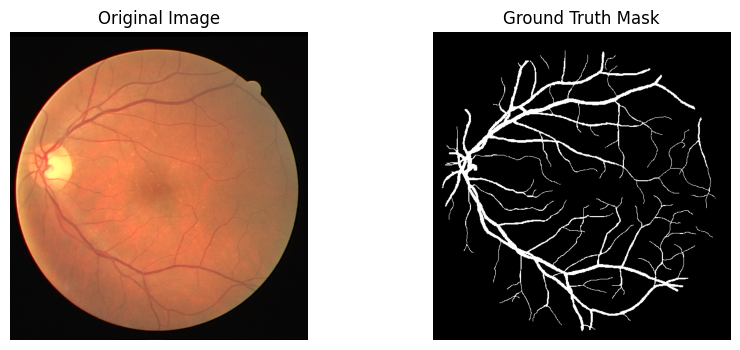

In [ ]:
drive_path = "/content/DRIVE"

train_images_path = os.path.join(drive_path, "training/images")
train_masks_path = os.path.join(drive_path, "training/1st_manual")

image_files = sorted(os.listdir(train_images_path))
mask_files = sorted(os.listdir(train_masks_path))

print("Number of training images:", len(image_files))
print("Number of training masks:", len(mask_files))

sample_img_path = os.path.join(train_images_path, image_files[0])
sample_mask_path = os.path.join(train_masks_path, mask_files[0])

image = cv2.imread(sample_img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()


Processed image shape: (584, 565)
Processed mask unique values: [0. 1.]


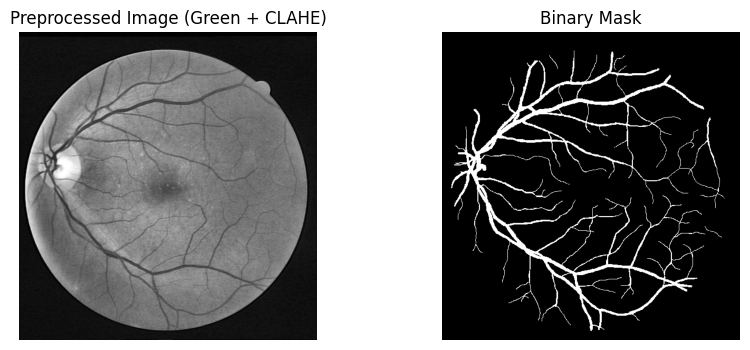

In [ ]:
def preprocess_image(image):
    green = image[:, :, 1]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(green)

    enhanced = enhanced.astype(np.float32) / 255.0

    return enhanced

def preprocess_mask(mask):
    mask = mask.astype(np.float32)
    mask = mask / 255.0
    mask = (mask > 0.5).astype(np.float32)
    return mask

processed_image = preprocess_image(image)
processed_mask = preprocess_mask(mask)

print("Processed image shape:", processed_image.shape)
print("Processed mask unique values:", np.unique(processed_mask))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(processed_image, cmap="gray")
plt.title("Preprocessed Image (Green + CLAHE)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed_mask, cmap="gray")
plt.title("Binary Mask")
plt.axis("off")

plt.show()


In [ ]:
class DriveDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.image_files)

    def preprocess_image(self, image):
        green = image[:, :, 1]

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(green)

        enhanced = enhanced.astype(np.float32) / 255.0
        return enhanced

    def preprocess_mask(self, mask):
        mask = mask.astype(np.float32) / 255.0
        mask = (mask > 0.5).astype(np.float32)
        return mask

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (512, 512))
        mask  = cv2.resize(mask,  (512, 512))

        image = self.preprocess_image(image)
        mask = self.preprocess_mask(mask)

        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [ ]:
image_dir = "/content/DRIVE/training/images"
mask_dir = "/content/DRIVE/training/1st_manual"

In [ ]:
dataset = DriveDataset(image_dir, mask_dir)

In [ ]:
train_dataset = DriveDataset(train_images_path, train_masks_path)

print("Dataset size:", len(train_dataset))

sample_img, sample_mask = train_dataset[0]

print("Image tensor shape:", sample_img.shape)
print("Mask tensor shape:", sample_mask.shape)

Dataset size: 20
Image tensor shape: torch.Size([1, 512, 512])
Mask tensor shape: torch.Size([1, 512, 512])


In [ ]:
from torch.utils.data import random_split, DataLoader

full_dataset = DriveDataset(image_dir, mask_dir)

dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

print("Total images:", dataset_size)
print("Train size:", train_size)
print("Val size:", val_size)

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

Total images: 20
Train size: 16
Val size: 4


In [ ]:
from torch.utils.data import DataLoader

batch_size = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [ ]:
train_image_dir = "/content/DRIVE/training/images"
train_mask_dir  = "/content/DRIVE/training/1st_manual"

test_image_dir  = "/content/DRIVE/test/images"
test_mask_dir   = "/content/DRIVE/test/1st_manual"

In [ ]:
test_dataset = DriveDataset(test_image_dir, test_mask_dir)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv = ConvBlock(in_channels, out_channels)

        self.skip = nn.Sequential()
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x) + self.skip(x)

In [ ]:
# Test Residual Block
test_input = torch.randn(1, 1, 584, 565).to(device)
block = ResidualBlock(1, 64).to(device)

output = block(test_input)
print("Output shape:", output.shape)

Output shape: torch.Size([1, 64, 584, 565])


In [ ]:
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

In [ ]:
g = torch.randn(1, 64, 292, 282).to(device)
x = torch.randn(1, 64, 292, 282).to(device)

att_gate = AttentionGate(64, 64, 32).to(device)
out = att_gate(g, x)

print("Attention output shape:", out.shape)

Attention output shape: torch.Size([1, 64, 292, 282])


In [ ]:
class AttentionResUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(AttentionResUNet, self).__init__()

        # Encoder
        self.enc1 = ResidualBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ResidualBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ResidualBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = ResidualBlock(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ResidualBlock(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att4 = AttentionGate(512, 512, 256)
        self.dec4 = ResidualBlock(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att3 = AttentionGate(256, 256, 128)
        self.dec3 = ResidualBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att2 = AttentionGate(128, 128, 64)
        self.dec2 = ResidualBlock(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att1 = AttentionGate(64, 64, 32)
        self.dec1 = ResidualBlock(128, 64)

        # Output
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        # Bottleneck
        b = self.bottleneck(p4)

        # Decoder
        d4 = self.up4(b)
        e4 = self.att4(d4, e4)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        e3 = self.att3(d3, e3)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)

        return out

In [ ]:
model = AttentionResUNet().to(device)

test_input = torch.randn(1, 1, 512, 512).to(device)
output = model(test_input)

print("Model output shape:", output.shape)

Model output shape: torch.Size([1, 1, 512, 512])


In [ ]:
import torch.nn.functional as F


def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)  # apply sigmoid
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return 1 - dice

In [ ]:
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce = self.bce(pred, target)
        dice = dice_loss(pred, target)
        return bce + dice

In [ ]:
criterion = BCEDiceLoss()

In [ ]:
pred = torch.randn(4, 1, 512, 512).to(device)
target = torch.randint(0, 2, (4, 1, 512, 512)).float().to(device)

loss = criterion(pred, target)
print("Loss value:", loss.item())

Loss value: 1.3043758869171143


In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:

num_epochs = 50

for epoch in range(num_epochs):
    model.train()

    epoch_loss = 0
    epoch_acc = 0
    epoch_dice = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        correct = (preds == masks).float().sum()
        total = torch.numel(preds)
        acc = correct / total
        epoch_acc += acc.item()

        intersection = (preds * masks).sum()
        dice = (2. * intersection + 1e-6) / (preds.sum() + masks.sum() + 1e-6)
        epoch_dice += dice.item()

    avg_loss = epoch_loss / len(train_loader)
    avg_acc = epoch_acc / len(train_loader)
    avg_dice = epoch_dice / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {avg_loss:.4f} | "
          f"Pixel Acc: {avg_acc:.4f} | "
          f"Dice: {avg_dice:.4f}")


Epoch [1/50] Loss: 1.3597 | Pixel Acc: 0.8728 | Dice: 0.2759
Epoch [2/50] Loss: 1.1952 | Pixel Acc: 0.8958 | Dice: 0.5537
Epoch [3/50] Loss: 1.0694 | Pixel Acc: 0.9060 | Dice: 0.5954
Epoch [4/50] Loss: 0.9752 | Pixel Acc: 0.9288 | Dice: 0.6565
Epoch [5/50] Loss: 0.9030 | Pixel Acc: 0.9390 | Dice: 0.6892
Epoch [6/50] Loss: 0.8428 | Pixel Acc: 0.9460 | Dice: 0.7109
Epoch [7/50] Loss: 0.7827 | Pixel Acc: 0.9490 | Dice: 0.7255
Epoch [8/50] Loss: 0.7271 | Pixel Acc: 0.9520 | Dice: 0.7340
Epoch [9/50] Loss: 0.6644 | Pixel Acc: 0.9554 | Dice: 0.7484
Epoch [10/50] Loss: 0.5940 | Pixel Acc: 0.9573 | Dice: 0.7551
Epoch [11/50] Loss: 0.5197 | Pixel Acc: 0.9609 | Dice: 0.7609
Epoch [12/50] Loss: 0.4578 | Pixel Acc: 0.9591 | Dice: 0.7479
Epoch [13/50] Loss: 0.4275 | Pixel Acc: 0.9614 | Dice: 0.7467
Epoch [14/50] Loss: 0.3969 | Pixel Acc: 0.9617 | Dice: 0.7699
Epoch [15/50] Loss: 0.3847 | Pixel Acc: 0.9629 | Dice: 0.7690
Epoch [16/50] Loss: 0.3693 | Pixel Acc: 0.9642 | Dice: 0.7795
Epoch [17/50] Los

Final Evaluation Results:
Dice Score : 0.9175
IoU Score  : 0.8476
F1 Score   : 0.9176
MCC        : 0.9100
AUC        : 0.9961


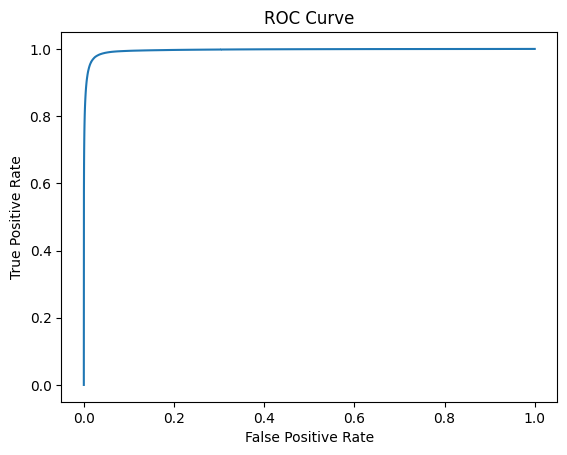

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, matthews_corrcoef

model.eval()

total_dice = 0
total_iou = 0

all_probs = []
all_preds = []
all_masks = []

with torch.no_grad():
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        # Flatten tensors
        preds_flat = preds.view(-1)
        masks_flat = masks.view(-1)
        probs_flat = probs.view(-1)

        # Dice
        intersection = (preds_flat * masks_flat).sum()
        dice = (2. * intersection + 1e-6) / (
            preds_flat.sum() + masks_flat.sum() + 1e-6
        )

        # IoU
        union = preds_flat.sum() + masks_flat.sum() - intersection
        iou = (intersection + 1e-6) / (union + 1e-6)

        total_dice += dice.item()
        total_iou += iou.item()

        all_probs.extend(probs_flat.cpu().numpy())
        all_preds.extend(preds_flat.cpu().numpy())
        all_masks.extend(masks_flat.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_masks = np.array(all_masks)


f1 = f1_score(all_masks, all_preds)
mcc = matthews_corrcoef(all_masks, all_preds)
auc = roc_auc_score(all_masks, all_probs)

fpr, tpr, _ = roc_curve(all_masks, all_probs)

avg_dice = total_dice / len(train_loader)
avg_iou = total_iou / len(train_loader)

print("Final Evaluation Results:")
print(f"Dice Score : {avg_dice:.4f}")
print(f"IoU Score  : {avg_iou:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"MCC        : {mcc:.4f}")
print(f"AUC        : {auc:.4f}")

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

model.eval()

all_probs = []
all_masks = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        # Flatten
        probs_flat = probs.view(-1)
        masks_flat = masks.view(-1)

        all_probs.extend(probs_flat.cpu().numpy())
        all_masks.extend(masks_flat.cpu().numpy())

all_probs = np.array(all_probs)
all_masks = np.array(all_masks)

fpr, tpr, thresholds = roc_curve(all_masks, all_probs)
auc = roc_auc_score(all_masks, all_probs)

J = tpr - fpr
ix = np.argmax(J)
best_threshold = thresholds[ix]

print("Validation AUC:", round(auc, 4))
print("Best Threshold (from validation set):", best_threshold)

Validation AUC: 0.9665
Best Threshold (from validation set): 0.0017752774


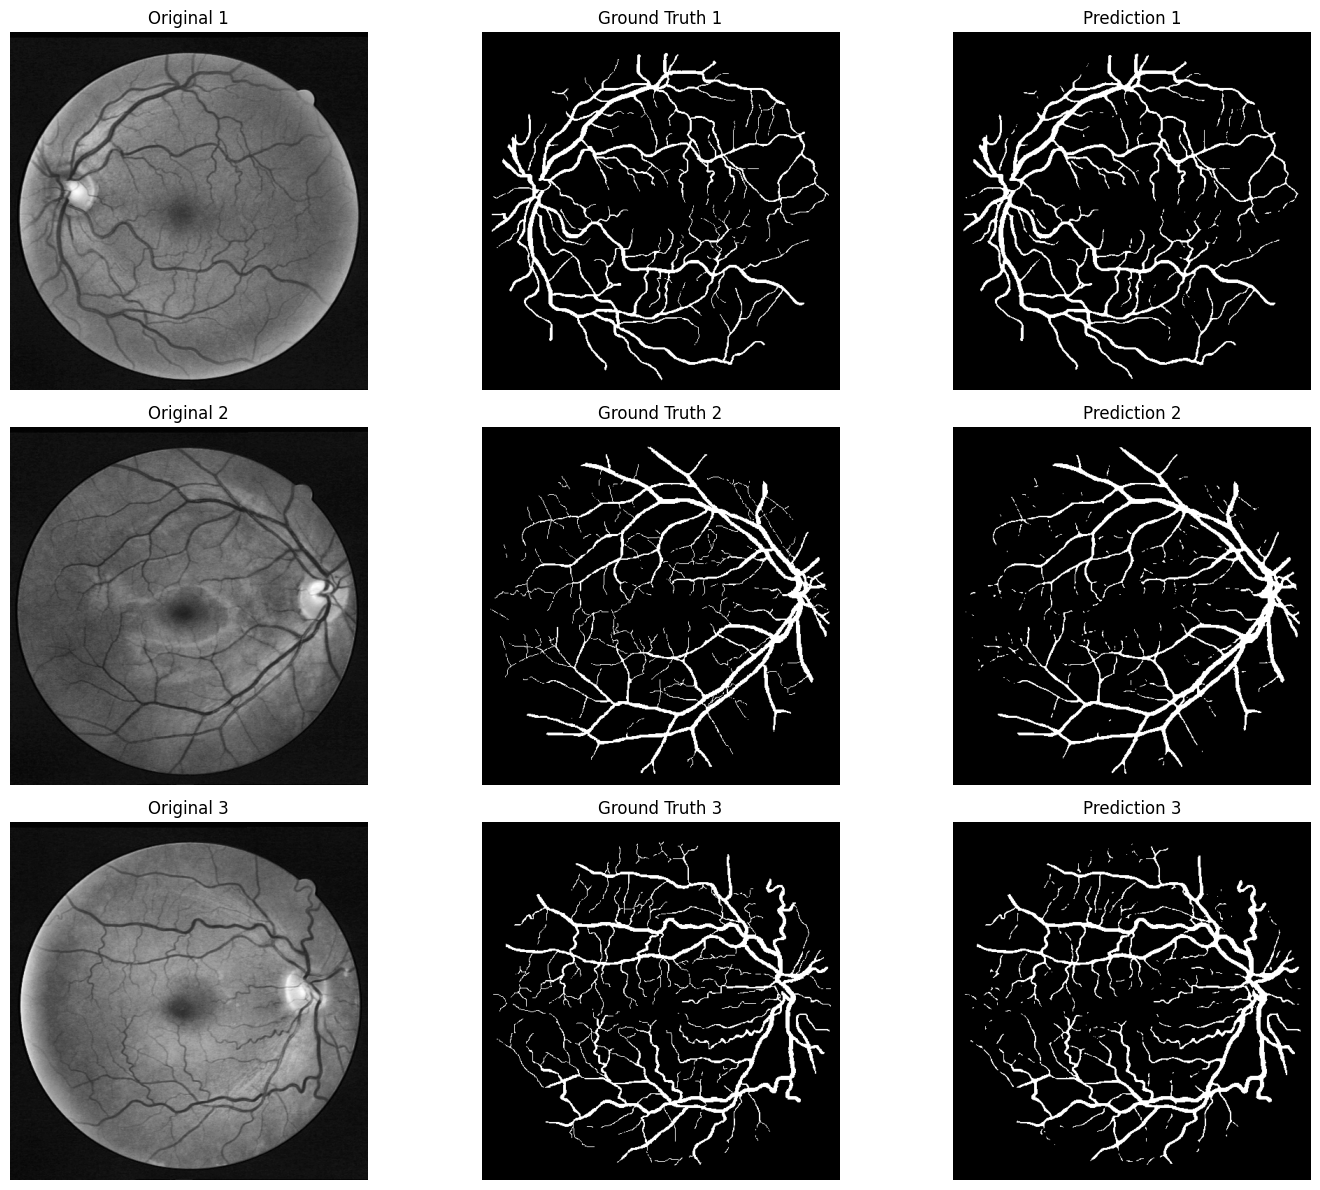

In [ ]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.4).float()

num_samples = 3

plt.figure(figsize=(15, 12))

for i in range(num_samples):

    image = images[i].detach().cpu().squeeze().numpy()
    mask = masks[i].detach().cpu().squeeze().numpy()
    pred = preds[i].detach().cpu().squeeze().numpy()

    # Original
    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Original {i+1}")
    plt.axis("off")

    # Ground Truth
    plt.subplot(num_samples, 3, i*3 + 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Ground Truth {i+1}")
    plt.axis("off")

    # Prediction
    plt.subplot(num_samples, 3, i*3 + 3)
    plt.imshow(pred, cmap='gray')
    plt.title(f"Prediction {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


===== TEST RESULTS =====
Dice Score : 0.7830
IoU Score  : 0.6436
F1 Score   : 0.7834
MCC        : 0.7653
AUC        : 0.9699


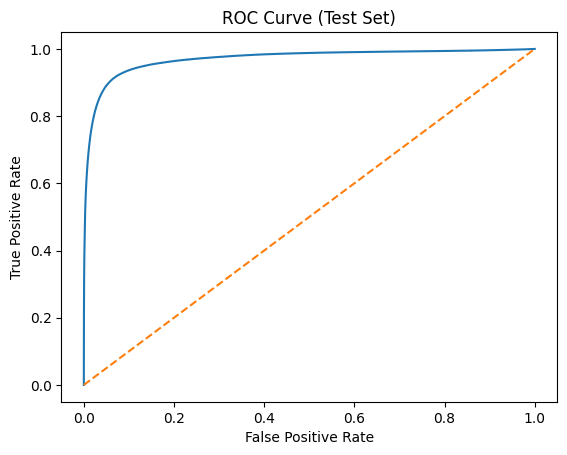

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, matthews_corrcoef

model.eval()

total_dice = 0
total_iou = 0

all_probs = []
all_preds = []
all_masks = []

with torch.no_grad():
    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        # Flatten
        preds_flat = preds.view(-1)
        masks_flat = masks.view(-1)
        probs_flat = probs.view(-1)

        # Dice
        intersection = (preds_flat * masks_flat).sum()
        dice = (2. * intersection + 1e-6) / (
            preds_flat.sum() + masks_flat.sum() + 1e-6
        )

        # IoU
        union = preds_flat.sum() + masks_flat.sum() - intersection
        iou = (intersection + 1e-6) / (union + 1e-6)

        total_dice += dice.item()
        total_iou += iou.item()

        # Store for sklearn metrics
        all_probs.extend(probs_flat.cpu().numpy())
        all_preds.extend(preds_flat.cpu().numpy())
        all_masks.extend(masks_flat.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_masks = np.array(all_masks)

f1 = f1_score(all_masks, all_preds)
mcc = matthews_corrcoef(all_masks, all_preds)
auc = roc_auc_score(all_masks, all_probs)

fpr, tpr, _ = roc_curve(all_masks, all_probs)

avg_dice = total_dice / len(test_loader)
avg_iou = total_iou / len(test_loader)

print("===== TEST RESULTS =====")
print(f"Dice Score : {avg_dice:.4f}")
print(f"IoU Score  : {avg_iou:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"MCC        : {mcc:.4f}")
print(f"AUC        : {auc:.4f}")

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.show()

In [ ]:
import torch
import os
import numpy as np
from torchvision.utils import save_image

best_threshold = 0.0017752774
save_dir = "test_predictions"
os.makedirs(save_dir, exist_ok=True)

model.eval()

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):

        images = images.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > best_threshold).float()

        for i in range(images.size(0)):
            save_path = os.path.join(save_dir, f"pred_{idx}_{i}.png")
            save_image(preds[i], save_path)

print("Test predictions saved in folder:", save_dir)

Test predictions saved in folder: test_predictions


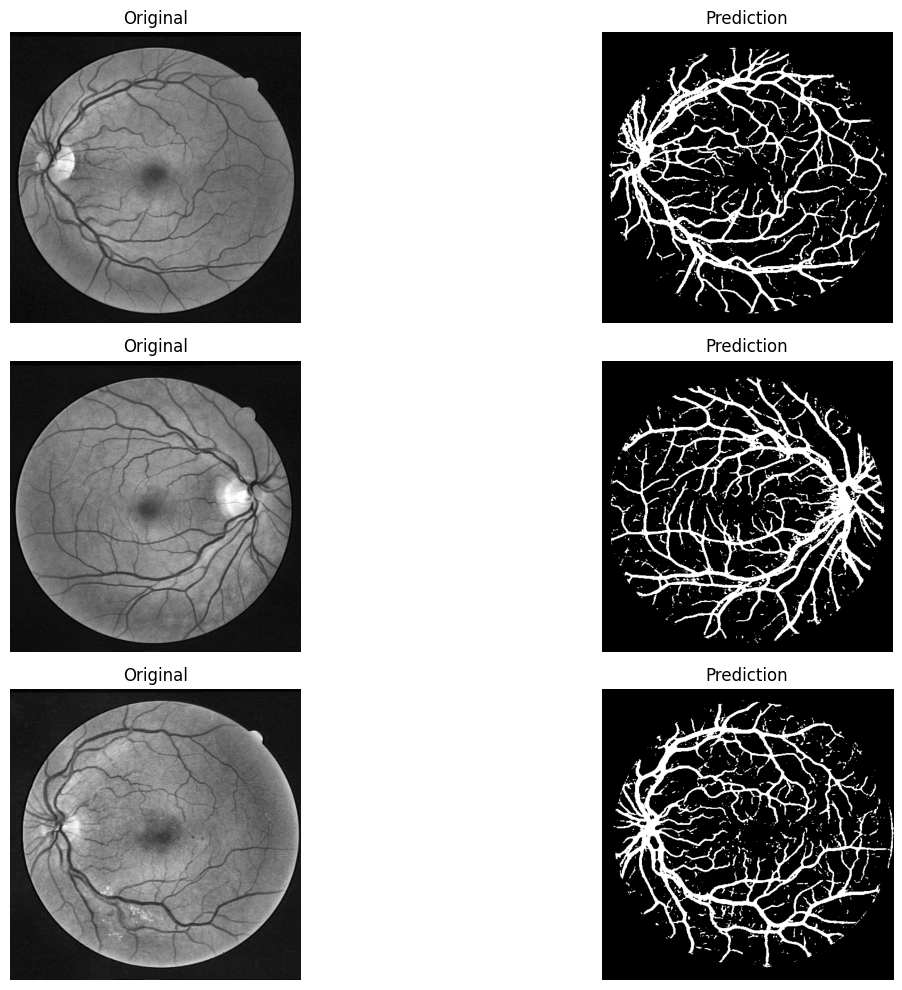

In [ ]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    probs = torch.sigmoid(outputs)
    preds = (probs > best_threshold).float()

num_samples = 3

plt.figure(figsize=(15, 10))

for i in range(num_samples):

    image = images[i].cpu().squeeze().numpy()
    pred = preds[i].cpu().squeeze().numpy()

    # Original
    plt.subplot(num_samples, 2, i*2 + 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Prediction
    plt.subplot(num_samples, 2, i*2 + 2)
    plt.imshow(pred, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()